In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pickle
import numpy as np

def check_look_vec_normalization(root_folder):
    epsilon = 1e-5  # Tolerance for floating point errors
    unnormalized_files = []

    for dirpath, dirnames, filenames in os.walk(root_folder):
        for filename in filenames:
            if filename.endswith('.pkl'):
                filepath = os.path.join(dirpath, filename)

                try:
                    with open(filepath, 'rb') as f:
                        data = pickle.load(f)
                        look_vec = np.array(data['look_vec'])
                        norm = np.linalg.norm(look_vec)

                        if not np.isclose(norm, 1.0, atol=epsilon):
                            unnormalized_files.append((filepath, look_vec, norm))

                except Exception as e:
                    print(f"⚠️ Error reading {filepath}: {e}")

    if unnormalized_files:
        print("\n⚠️ Found unnormalized look_vec:")
        for fpath, vec, n in unnormalized_files:
            print(f"File: {fpath} | Vector: {vec} | Norm: {n:.6f}")
    else:
        print("\n✅ All look_vecs are normalized.")

# Example usage
root_folder = "/content/drive/My Drive/GazePose/SynthEyes_data/"
check_look_vec_normalization(root_folder)


✅ All look_vecs are normalized.


In [ ]:
import os
import pickle
import numpy as np
from PIL import Image
import torch
from torchvision import transforms
from tqdm import tqdm

# Configuration
INPUT_DIR = "/content/drive/My Drive/GazePose/SynthEyes_data/"
OUTPUT_DIR = "/content/drive/My Drive/GazePose/preprocessed_eyes_resnet18"
IMAGE_SIZE = (224, 224)  # ResNet-18 input size
os.makedirs(OUTPUT_DIR, exist_ok=True)

def extract_gaze_vector(pkl_path):
    """Extract and normalize ONLY the gaze vector"""
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)

    gaze_vec = np.array(data['look_vec'], dtype=np.float32)
    return gaze_vec

def process_eye_image(image_path):
    """Preprocess image for ResNet18"""
    transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                           std=[0.229, 0.224, 0.225])
    ])
    return transform(Image.open(image_path).convert('RGB'))

def run_preprocessing():
    # Find all valid (image, pkl) pairs
    samples = []
    print("Scanning dataset folders...")
    for subdir in tqdm(os.listdir(INPUT_DIR)):
        subdir_path = os.path.join(INPUT_DIR, subdir)
        if os.path.isdir(subdir_path):
            for file in os.listdir(subdir_path):
                if file.endswith('.pkl'):
                    pkl_path = os.path.join(subdir_path, file)
                    img_path = os.path.join(subdir_path, file.replace('.pkl', '.png'))
                    if os.path.exists(img_path):
                        samples.append((img_path, pkl_path))

    # Process each sample
    print(f"\nProcessing {len(samples)} samples...")
    for img_path, pkl_path in tqdm(samples, desc="Preprocessing"):
        try:
            # Extract and normalize gaze vector
            gaze_vec = extract_gaze_vector(pkl_path)

            # Preprocess image
            img_tensor = process_eye_image(img_path)

            # Save as .npz (ready for PyTorch)
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            np.savez_compressed(
                os.path.join(OUTPUT_DIR, f"{base_name}.npz"),
                image=img_tensor.numpy(),  # Shape: (3, 224, 224)
                gaze=gaze_vec             # Normalized (3,)
            )
        except Exception as e:
            print(f"Skipping {img_path}: {str(e)}")
            continue

    print(f"\nPreprocessing complete! Output saved to {OUTPUT_DIR}")

if __name__ == "__main__":
    run_preprocessing()

Scanning dataset folders...


100%|██████████| 11/11 [00:32<00:00,  2.99s/it]



Processing 11382 samples...


Preprocessing: 100%|██████████| 11382/11382 [1:25:02<00:00,  2.23it/s]


Preprocessing complete! Output saved to /content/drive/My Drive/GazePose/preprocessed_eyes_resnet18


Loading data: 100%|██████████| 5000/5000 [02:26<00:00, 34.23it/s] 


Loaded 5000 gaze vectors
Mean vector: [ 0.0184 -0.0371 -0.8563]
Std deviation: [0.3887 0.3165 0.1178]


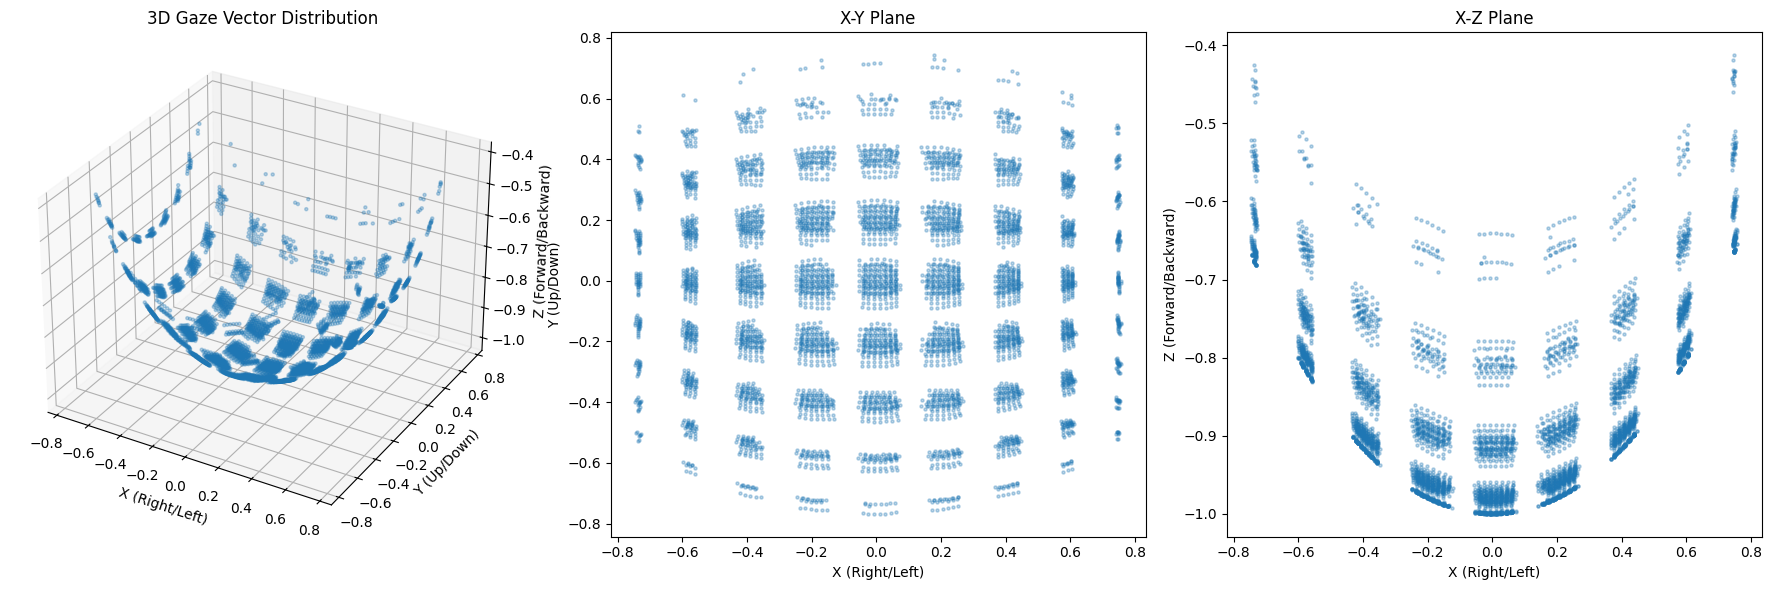

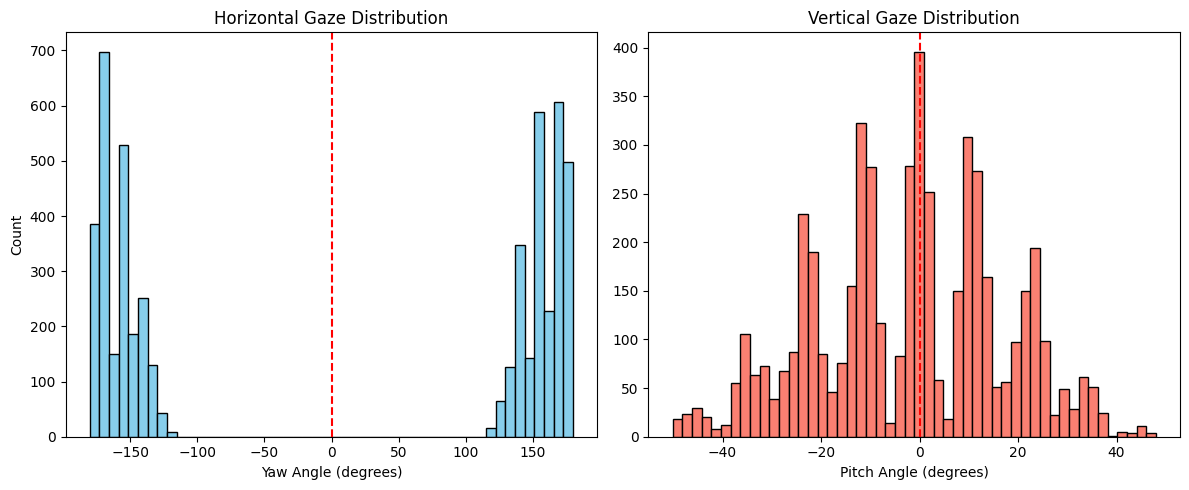

Yaw range: [-180.0°, 179.8°]
Pitch range: [-50.2°, 48.0°]
Mean yaw: 7.3° | Mean pitch: -2.3°

Directional Distribution:
Right gazes: 35.7%
Left gazes: 31.2%
Up gazes: 24.1%
Down gazes: 32.0%
Center gazes: 26.5%


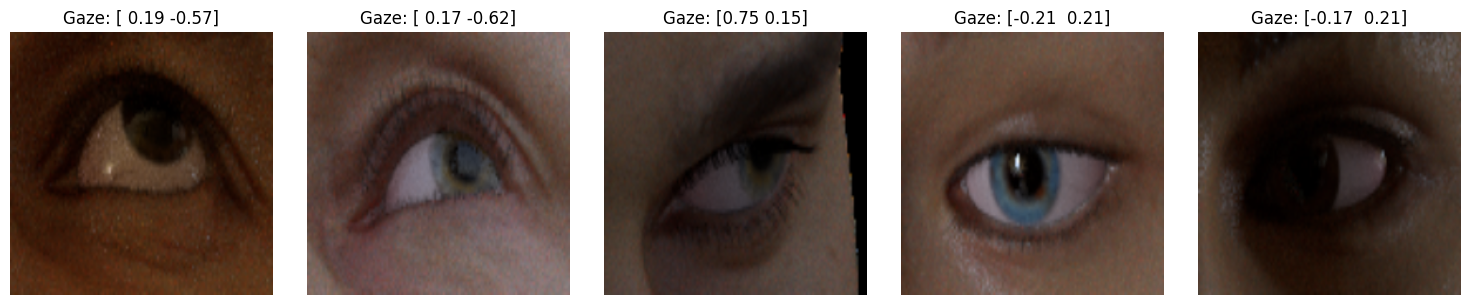

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
from tqdm import tqdm

# Configuration
DATA_DIR = "/content/drive/My Drive/GazePose/preprocessed_eyes_resnet18"

def load_all_data(data_dir, max_samples=5000):
    """Load a subset of the preprocessed data"""
    files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.npz')]
    files = files[:max_samples]  # Limit for performance

    gazes = []
    for f in tqdm(files, desc="Loading data"):
        data = np.load(f)
        gazes.append(data['gaze'])

    return np.array(gazes)

def plot_gaze_distribution(gazes):
    """Plot 3D distribution of gaze vectors"""
    fig = plt.figure(figsize=(18, 6))

    # 3D Scatter plot
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(gazes[:,0], gazes[:,1], gazes[:,2], alpha=0.3, s=5)
    ax1.set_xlabel('X (Right/Left)')
    ax1.set_ylabel('Y (Up/Down)')
    ax1.set_zlabel('Z (Forward/Backward)')
    ax1.set_title('3D Gaze Vector Distribution')

    # 2D Projections
    ax2 = fig.add_subplot(132)
    ax2.scatter(gazes[:,0], gazes[:,1], alpha=0.3, s=5)
    ax2.set_xlabel('X (Right/Left)')
    ax2.set_ylabel('Y (Up/Down)')
    ax2.set_title('X-Y Plane')

    ax3 = fig.add_subplot(133)
    ax3.scatter(gazes[:,0], gazes[:,2], alpha=0.3, s=5)
    ax3.set_xlabel('X (Right/Left)')
    ax3.set_ylabel('Z (Forward/Backward)')
    ax3.set_title('X-Z Plane')

    plt.tight_layout()
    plt.show()

def plot_angular_distribution(gazes):
    """Convert to yaw/pitch angles and plot distribution"""
    # Convert to spherical coordinates (angles in degrees)
    yaw = np.arctan2(gazes[:,0], gazes[:,2]) * 180/np.pi
    pitch = np.arctan2(gazes[:,1], np.sqrt(gazes[:,0]**2 + gazes[:,2]**2)) * 180/np.pi

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Yaw distribution
    ax1.hist(yaw, bins=50, color='skyblue', edgecolor='black')
    ax1.set_xlabel('Yaw Angle (degrees)')
    ax1.set_ylabel('Count')
    ax1.set_title('Horizontal Gaze Distribution')
    ax1.axvline(0, color='red', linestyle='--')

    # Pitch distribution
    ax2.hist(pitch, bins=50, color='salmon', edgecolor='black')
    ax2.set_xlabel('Pitch Angle (degrees)')
    ax2.set_title('Vertical Gaze Distribution')
    ax2.axvline(0, color='red', linestyle='--')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"Yaw range: [{yaw.min():.1f}°, {yaw.max():.1f}°]")
    print(f"Pitch range: [{pitch.min():.1f}°, {pitch.max():.1f}°]")
    print(f"Mean yaw: {yaw.mean():.1f}° | Mean pitch: {pitch.mean():.1f}°")

def check_data_balance(gazes):
    """Check for directional biases"""
    # Define quadrants (adjust thresholds as needed)
    right = gazes[:,0] > 0.2
    left = gazes[:,0] < -0.2
    up = gazes[:,1] > 0.2
    down = gazes[:,1] < -0.2

    print("\nDirectional Distribution:")
    print(f"Right gazes: {100*right.mean():.1f}%")
    print(f"Left gazes: {100*left.mean():.1f}%")
    print(f"Up gazes: {100*up.mean():.1f}%")
    print(f"Down gazes: {100*down.mean():.1f}%")

    # Check center concentration
    center = np.sqrt(gazes[:,0]**2 + gazes[:,1]**2) < 0.3
    print(f"Center gazes: {100*center.mean():.1f}%")

def visualize_sample_images(data_dir, n_samples=5):
    """Display random sample images with gaze vectors"""
    files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.npz')]
    samples = np.random.choice(files, n_samples)

    fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))
    for ax, f in zip(axes, samples):
        data = np.load(f)
        img = data['image'].transpose(1, 2, 0)  # CHW to HWC
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)

        ax.imshow(img)
        ax.set_title(f"Gaze: {data['gaze'][:2].round(2)}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Load the preprocessed data
    gazes = load_all_data(DATA_DIR)

    # 1. Basic statistics
    print(f"Loaded {len(gazes)} gaze vectors")
    print(f"Mean vector: {gazes.mean(axis=0).round(4)}")
    print(f"Std deviation: {gazes.std(axis=0).round(4)}")

    # 2. 3D and 2D visualizations
    plot_gaze_distribution(gazes)

    # 3. Angular distributions
    plot_angular_distribution(gazes)

    # 4. Check for biases
    check_data_balance(gazes)

    # 5. Visualize sample images
    visualize_sample_images(DATA_DIR)

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split

# Configuration
DATA_DIR = "/content/drive/My Drive/GazePose/preprocessed_eyes_resnet18"
CHECKPOINT_DIR = "/content/drive/My Drive/GazePose/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 100
PATIENCE = 5
SPLIT_RATIO = [0.7, 0.15, 0.15]  # Train/Val/Test

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

class GazeDataset(Dataset):
    def __init__(self, npz_files):
        self.files = npz_files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = dict(np.load(self.files[idx]))
        return (
            torch.tensor(data['image'], dtype=torch.float32),
            torch.tensor(data['gaze'], dtype=torch.float32)
        )

class GazeResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Freeze initial layers
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Unfreeze last two layers
        for param in list(self.base_model.children())[-2:]:
            for p in param.parameters():
                p.requires_grad = True

        # Modify final layers
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        return self.base_model(x)

def angular_error(preds, labels):
    preds_norm = preds / torch.norm(preds, dim=1, keepdim=True)
    labels_norm = labels / torch.norm(labels, dim=1, keepdim=True)
    dot_product = torch.sum(preds_norm * labels_norm, dim=1)
    dot_product = torch.clamp(dot_product, -1.0, 1.0)
    return torch.mean(torch.acos(dot_product)) * 180 / np.pi

def dynamic_weighted_mse_loss(outputs, targets):
    pitches = targets[:, 1]
    upward_mask = pitches > 0
    weights = torch.ones_like(pitches)
    weights[upward_mask] = 1.5  # Upweight upward gazes
    return (torch.mean((outputs - targets)**2, dim=1) * weights).mean()

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_angular = 0.0

    with tqdm(loader, desc="Training", leave=False) as pbar:
        for images, gazes in pbar:
            images, gazes = images.to(device), gazes.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, gazes)
            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_angular += angular_error(outputs, gazes).item() * batch_size

            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    return total_loss / len(loader.dataset), total_angular / len(loader.dataset)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_angular = 0.0

    with torch.no_grad(), tqdm(loader, desc="Validating", leave=False) as pbar:
        for images, gazes in pbar:
            images, gazes = images.to(device), gazes.to(device)
            outputs = model(images)

            loss = criterion(outputs, gazes)
            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_angular += angular_error(outputs, gazes).item() * batch_size

            pbar.set_postfix({'val_loss': f"{loss.item():.4f}"})

    return total_loss / len(loader.dataset), total_angular / len(loader.dataset)

def main():
    # Load all .npz files
    all_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith('.npz')]

    # Split into train/val/test
    train_files, test_files = train_test_split(all_files, test_size=SPLIT_RATIO[2], random_state=42)
    train_files, val_files = train_test_split(
        train_files, test_size=SPLIT_RATIO[1]/(1 - SPLIT_RATIO[2]), random_state=42
    )

    print(f"\nDataset sizes:")
    print(f"Train: {len(train_files)}")
    print(f"Val:   {len(val_files)}")
    print(f"Test:  {len(test_files)}")

    # Create datasets and loaders
    train_set = GazeDataset(train_files)
    val_set = GazeDataset(val_files)
    test_set = GazeDataset(test_files)

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

    # Initialize model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nUsing device: {device}")
    model = GazeResNet18().to(device)

    # Loss and optimizer
    criterion = dynamic_weighted_mse_loss
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, verbose=True)

    # Training loop
    best_val_loss = float('inf')
    patience_counter = 0
    early_stop = False

    for epoch in range(1, EPOCHS+1):
        print(f"\nEpoch {epoch}/{EPOCHS}")
        train_loss, train_angular = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_angular = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Train Angular Error: {train_angular:.2f}°")
        print(f"Val Loss:   {val_loss:.4f} | Val Angular Error: {val_angular:.2f}°")

        # Checkpointing
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, os.path.join(CHECKPOINT_DIR, 'best_model.pth'))
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping triggered at epoch {epoch}")
                early_stop = True
                break

    # Final evaluation
    if not early_stop:
        print("\nTraining completed without early stopping")

    checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pth'))
    model.load_state_dict(checkpoint['model_state_dict'])

    test_loss, test_angular = validate(model, test_loader, criterion, device)
    print(f"\nFinal Test Results:")
    print(f"Loss: {test_loss:.4f}")
    print(f"Angular Error: {test_angular:.2f}°")

if __name__ == "__main__":
    main()


Dataset sizes:
Train: 7966
Val:   1708
Test:  1708

Using device: cpu

Epoch 1/100


Train Loss: 0.1251 | Train Angular Error: 26.53°
Val Loss:   0.0692 | Val Angular Error: 20.66°

Epoch 2/100


Train Loss: 0.0836 | Train Angular Error: 21.64°
Val Loss:   0.0631 | Val Angular Error: 19.89°

Epoch 3/100


Train Loss: 0.0784 | Train Angular Error: 20.98°
Val Loss:   0.0632 | Val Angular Error: 19.24°

Epoch 4/100


Train Loss: 0.0738 | Train Angular Error: 20.31°
Val Loss:   0.0663 | Val Angular Error: 20.08°

Epoch 5/100


...

Train Loss: 0.0478 | Train Angular Error: 17.08°
Val Loss:   0.0473 | Val Angular Error: 17.15°

Epoch 24/100


Train Loss: 0.0478 | Train Angular Error: 17.07°
Val Loss:   0.0469 | Val Angular Error: 17.09°

Epoch 25/100


Train Loss: 0.0474 | Train Angular Error: 16.99°
Val Loss:   0.0471 | Val Angular Error: 17.09°

Epoch 26/100


Train Loss: 0.0478 | Train Angular Error: 17.08°
Val Loss:   0.0466 | Val Angular Error: 16.97°

Epoch 27/100


Training:  14%|█▎        | 17/125 [02:09<13:47,  7.66s/it, loss=0.0499]

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import torchvision.transforms.functional as TF

# Configuration
DATA_DIR = "/content/drive/My Drive/GazePose/preprocessed_eyes_resnet18"
CHECKPOINT_DIR = "/content/drive/My Drive/GazePose/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.0005
EPOCHS = 100
PATIENCE = 7
SPLIT_RATIO = [0.7, 0.15, 0.15]

# Set random seeds
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

class GazeDataset(Dataset):
    def __init__(self, npz_files, augment=True):
        self.files = npz_files
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = dict(np.load(self.files[idx]))
        img_tensor = torch.tensor(data['image'], dtype=torch.float32)
        gaze = torch.tensor(data['gaze'], dtype=torch.float32)

        if self.augment:
            # Random horizontal flip
            if random.random() < 0.5:
                img_tensor = torch.flip(img_tensor, [-1])  # Flip width dimension
                gaze[0] *= -1  # Invert x-component for gaze vector

            # Color jitter
            if random.random() < 0.3:
                img_tensor = TF.adjust_brightness(img_tensor, random.uniform(0.9, 1.1))
                img_tensor = TF.adjust_contrast(img_tensor, random.uniform(0.9, 1.1))

            # Add Gaussian noise
            if random.random() < 0.2:
                noise = torch.randn_like(img_tensor) * 0.01
                img_tensor = img_tensor + noise

            # Small rotation
            if random.random() < 0.3:
                angle = random.uniform(-10, 10)
                img_tensor = TF.rotate(img_tensor, angle)

        return img_tensor, gaze

class GazeResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Freeze first 4 layers
        for i, (name, param) in enumerate(self.base_model.named_parameters()):
            if i < 30:
                param.requires_grad = False

        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3),
            nn.Tanh()
        )

    def forward(self, x):
        return self.base_model(x)

def angular_error(preds, labels):
    preds_norm = F.normalize(preds, p=2, dim=1)
    labels_norm = F.normalize(labels, p=2, dim=1)
    dot_product = (preds_norm * labels_norm).sum(dim=1)
    dot_product = torch.clamp(dot_product, -1.0, 1.0)
    return torch.mean(torch.acos(dot_product)) * 180 / np.pi

def adaptive_loss(outputs, targets):
    # Convert to angles for dynamic weighting
    yaw = torch.atan2(targets[:,0], targets[:,2]) * 180/np.pi
    pitch = torch.asin(targets[:,1]) * 180/np.pi

    # Dynamic weights
    weights = torch.ones_like(pitch)
    weights[torch.abs(yaw) > 30] *= 1.2  # Peripheral gazes
    weights[pitch > 15] *= 1.3  # Upward gazes

    # Cosine loss with weights
    cos_loss = 1 - F.cosine_similarity(outputs, targets)
    return (cos_loss * weights).mean()

def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, total_angular = 0.0, 0.0

    for images, gazes in tqdm(loader, desc="Training", leave=False):
        images, gazes = images.to(device), gazes.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = adaptive_loss(outputs, gazes)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_angular += angular_error(outputs, gazes).item() * images.size(0)

    return total_loss / len(loader.dataset), total_angular / len(loader.dataset)

def validate(model, loader, device):
    model.eval()
    total_loss, total_angular = 0.0, 0.0

    with torch.no_grad():
        for images, gazes in tqdm(loader, desc="Validating", leave=False):
            images, gazes = images.to(device), gazes.to(device)
            outputs = model(images)

            loss = adaptive_loss(outputs, gazes)
            total_loss += loss.item() * images.size(0)
            total_angular += angular_error(outputs, gazes).item() * images.size(0)

    return total_loss / len(loader.dataset), total_angular / len(loader.dataset)

def main():
    # Load and split data
    all_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith('.npz')]
    train_files, test_files = train_test_split(all_files, test_size=SPLIT_RATIO[2], random_state=42)
    train_files, val_files = train_test_split(train_files, test_size=SPLIT_RATIO[1]/(1-SPLIT_RATIO[2]), random_state=42)

    print(f"\nDataset sizes - Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

    # Create datasets and loaders
    train_set = GazeDataset(train_files, augment=True)
    val_set = GazeDataset(val_files, augment=False)
    test_set = GazeDataset(test_files, augment=False)

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

    # Initialize model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nUsing device: {device}")
    model = GazeResNet18().to(device)

    # Optimizer and scheduler
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5, verbose=True)

    # Training loop
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, EPOCHS+1):
        print(f"\nEpoch {epoch}/{EPOCHS}")
        train_loss, train_angular = train_epoch(model, train_loader, optimizer, device)
        val_loss, val_angular = validate(model, val_loader, device)

        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Angular: {train_angular:.2f}°")
        print(f"Val Loss:   {val_loss:.4f} | Angular: {val_angular:.2f}°")

        # Checkpointing
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, os.path.join(CHECKPOINT_DIR, 'first_best_model.pth'))
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping triggered at epoch {epoch}")
                break

    # Final evaluation
    checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, 'first_best_model.pth'))
    model.load_state_dict(checkpoint['model_state_dict'])
    test_loss, test_angular = validate(model, test_loader, device)

    print(f"\nFinal Test Results:")
    print(f"Loss: {test_loss:.4f} | Angular Error: {test_angular:.2f}°")

if __name__ == "__main__":
    main()


Dataset sizes - Train: 7966, Val: 1708, Test: 1708

Using device: cpu

Epoch 1/100


Train Loss: 0.1341 | Angular: 20.42°
Val Loss:   0.0162 | Angular: 7.97°

Epoch 2/100


Train Loss: 0.0723 | Angular: 14.33°
Val Loss:   0.0159 | Angular: 8.08°

Epoch 3/100


Train Loss: 0.0499 | Angular: 12.20°
Val Loss:   0.0114 | Angular: 6.74°

Epoch 4/100


Train Loss: 0.0434 | Angular: 11.26°
Val Loss:   0.0087 | Angular: 5.84°

Epoch 5/100


...

Train Loss: 0.0370 | Angular: 9.99°
Val Loss:   0.0079 | Angular: 5.65°

Epoch 8/100


Train Loss: 0.0370 | Angular: 10.05°
Val Loss:   0.0074 | Angular: 5.39°

Epoch 9/100


Train Loss: 0.0364 | Angular: 9.87°
Val Loss:   0.0075 | Angular: 5.44°

Epoch 10/100


Train Loss: 0.0345 | Angular: 9.49°
Val Loss:   0.0065 | Angular: 5.06°

Epoch 11/100


KeyboardInterrupt: 

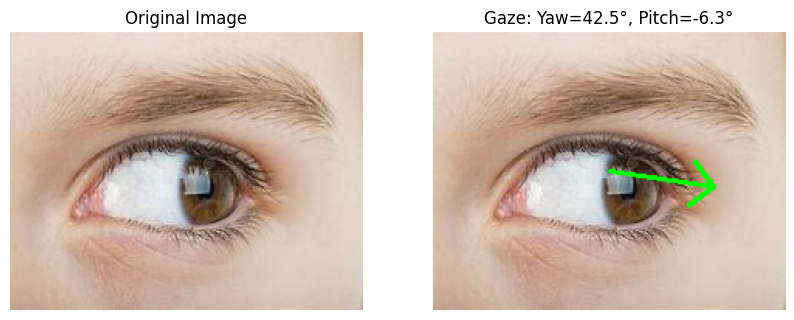


Predicted Gaze Direction: Looking Down Left
Raw Gaze Vector (x, y, z): [ 0.9072374  -0.14863755 -0.99131984]
Angles: Yaw = 42.5°, Pitch = -6.3°


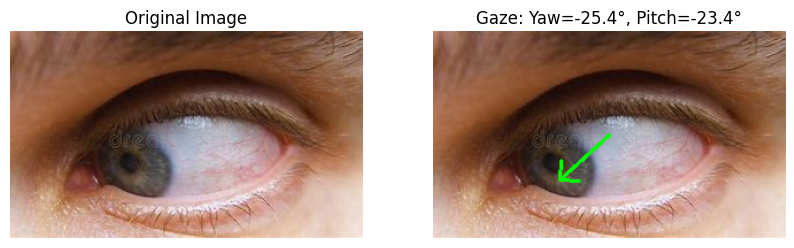


Predicted Gaze Direction: Looking Down Right
Raw Gaze Vector (x, y, z): [-0.41631314 -0.41982868 -0.87756944]
Angles: Yaw = -25.4°, Pitch = -23.4°


In [ ]:
import numpy as np
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import torch.nn as nn
from torchvision import models

class GazeResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        for i, (name, param) in enumerate(self.base_model.named_parameters()):
            if i < 30:
                param.requires_grad = False

        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3),
            nn.Tanh()
        )

    def forward(self, x):
        return self.base_model(x)


def load_model(model_path, device):
    model = GazeResNet18()
    state_dict = torch.load(model_path, map_location=device)['model_state_dict']
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model


def preprocess_image(image_path, device):
    img = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)
    return img_tensor, img


def draw_gaze(image, yaw, pitch, color=(0, 255, 0), length=100):
    img = np.array(image)
    h, w = img.shape[:2]

    x = length * np.sin(np.radians(yaw))
    y = -length * np.sin(np.radians(pitch))  # Inverted for display

    center = (w // 2, h // 2)
    end_point = (int(center[0] + x), int(center[1] + y))

    cv2.arrowedLine(img, center, end_point, color, 2, tipLength=0.3)
    return Image.fromarray(img)


def classify_gaze_direction(yaw_deg, pitch_deg, yaw_threshold=10, pitch_threshold=5):
    horizontal = ""
    vertical = ""

    if yaw_deg < -yaw_threshold:
        horizontal = "Right"
    elif yaw_deg > yaw_threshold:
        horizontal = "Left"
    else:
        horizontal = "Center"

    if pitch_deg < -pitch_threshold:
        vertical = "Down"
    elif pitch_deg > pitch_threshold:
        vertical = "Up"
    else:
        vertical = "Center"

    if horizontal == "Center" and vertical == "Center":
        return "Looking Center"
    elif horizontal == "Center":
        return f"Looking {vertical}"
    elif vertical == "Center":
        return f"Looking {horizontal}"
    else:
        return f"Looking {vertical} {horizontal}"


def test_model(image_path, model_path, device='cpu'):
    model = load_model(model_path, device)
    img_tensor, original_img = preprocess_image(image_path, device)

    with torch.no_grad():
        gaze_pred = model(img_tensor)

    gaze_pred = gaze_pred.cpu().numpy()[0]

    # Flip Y to match image plane logic
    gaze_pred[1] = -gaze_pred[1]

    # Convert to yaw and pitch in degrees
    yaw = np.degrees(np.arctan2(gaze_pred[0], -gaze_pred[2]))
    pitch = np.degrees(np.arcsin(gaze_pred[1] / np.linalg.norm(gaze_pred)))

    viz_img = draw_gaze(original_img, yaw, pitch)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(viz_img)
    plt.title(f"Gaze: Yaw={yaw:.1f}°, Pitch={pitch:.1f}°")
    plt.axis('off')
    plt.show()

    gaze_direction = classify_gaze_direction(yaw, pitch)
    print("\nPredicted Gaze Direction:", gaze_direction)
    print("Raw Gaze Vector (x, y, z):", gaze_pred)
    print("Angles: Yaw = {:.1f}°, Pitch = {:.1f}°".format(yaw, pitch))

    return gaze_pred, yaw, pitch


if __name__ == "__main__":
    MODEL_PATH = "/content/drive/My Drive/GazePose/checkpoints/first_best_model.pth"
    TEST_IMAGE = "/content/drive/My Drive/GazePose/OIP.jpeg"
    IMAGE = "/content/drive/My Drive/GazePose/download.jpeg"

    gaze_vector, yaw, pitch = test_model(TEST_IMAGE, MODEL_PATH)
    gaze_vector, yaw, pitch = test_model(IMAGE, MODEL_PATH)

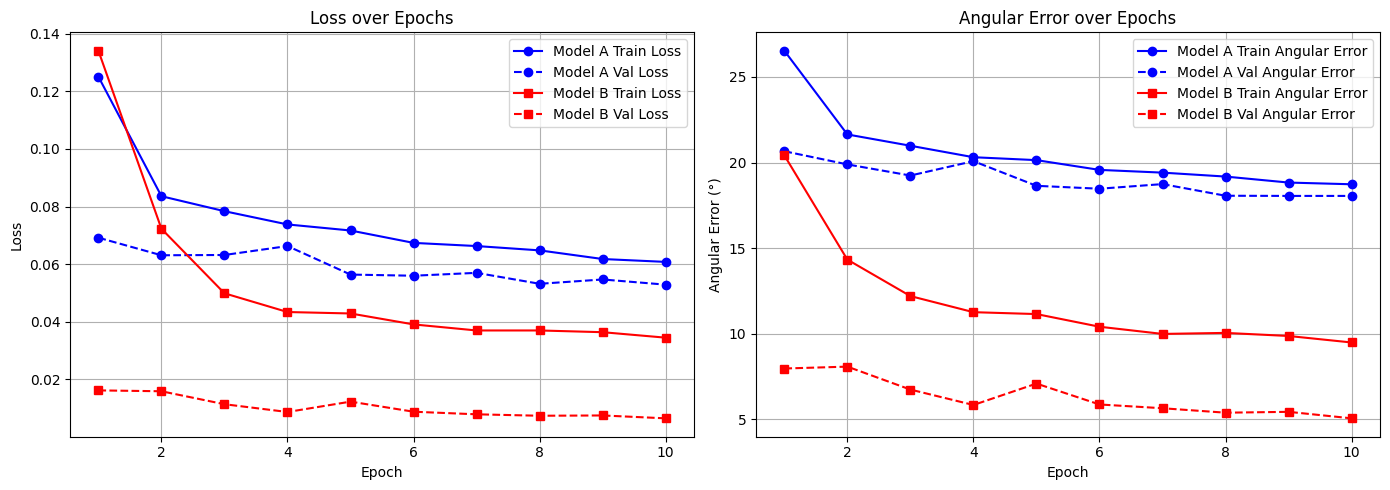

In [ ]:
import matplotlib.pyplot as plt

# Model A data (unchanged)
modelA_train_loss = [0.1251, 0.0836, 0.0784, 0.0738, 0.0717, 0.0674, 0.0663, 0.0648, 0.0618, 0.0608]
modelA_val_loss   = [0.0692, 0.0631, 0.0632, 0.0663, 0.0564, 0.0560, 0.0570, 0.0532, 0.0547, 0.0529]
modelA_train_ang  = [26.53, 21.64, 20.98, 20.31, 20.14, 19.57, 19.41, 19.18, 18.83, 18.73]
modelA_val_ang    = [20.66, 19.89, 19.24, 20.08, 18.64, 18.47, 18.74, 18.06, 18.05, 18.05]

# Corrected Model B data (10 epochs from training logs)
modelB_train_loss = [0.1341, 0.0723, 0.0499, 0.0434, 0.0429, 0.0391, 0.0370, 0.0370, 0.0364, 0.0345]
modelB_val_loss   = [0.0162, 0.0159, 0.0114, 0.0087, 0.0123, 0.0088, 0.0079, 0.0074, 0.0075, 0.0065]
modelB_train_ang  = [20.42, 14.33, 12.20, 11.26, 11.15, 10.41, 9.99, 10.05, 9.87, 9.49]
modelB_val_ang    = [7.97, 8.08, 6.74, 5.84, 7.09, 5.87, 5.65, 5.39, 5.44, 5.06]

epochs_A = list(range(1, len(modelA_train_loss)+1))
epochs_B = list(range(1, len(modelB_train_loss)+1))  # Now 1-10 for Model B

plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_A, modelA_train_loss, 'b-o', label='Model A Train Loss')
plt.plot(epochs_A, modelA_val_loss, 'b--o', label='Model A Val Loss')
plt.plot(epochs_B, modelB_train_loss, 'r-s', label='Model B Train Loss')
plt.plot(epochs_B, modelB_val_loss, 'r--s', label='Model B Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.grid(True)

# Angular Error Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_A, modelA_train_ang, 'b-o', label='Model A Train Angular Error')
plt.plot(epochs_A, modelA_val_ang, 'b--o', label='Model A Val Angular Error')
plt.plot(epochs_B, modelB_train_ang, 'r-s', label='Model B Train Angular Error')
plt.plot(epochs_B, modelB_val_ang, 'r--s', label='Model B Val Angular Error')
plt.xlabel("Epoch")
plt.ylabel("Angular Error (°)")
plt.title("Angular Error over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()